Задание 1. Численное нахождение и визуализация сопряженной функции (Преобразование Лежандра-Фенхеля)

Формула сопряжённой функции (также известная как преобразование Лежандра — Фенхеля) — это один из важнейших инструментов в выпуклом анализе и оптимизации. Она позволяет взглянуть на исходную функцию через призму её касательных (опорных) гиперпланов.

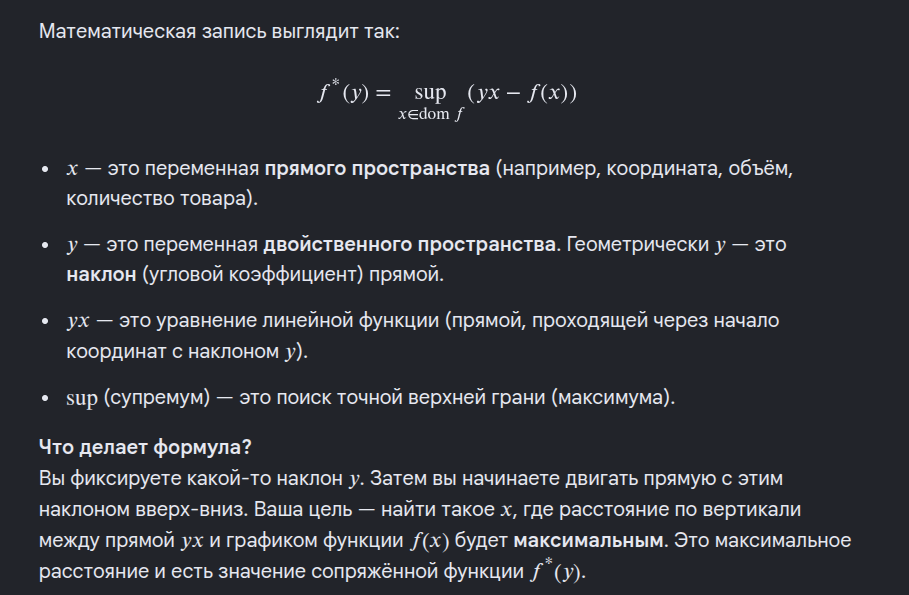

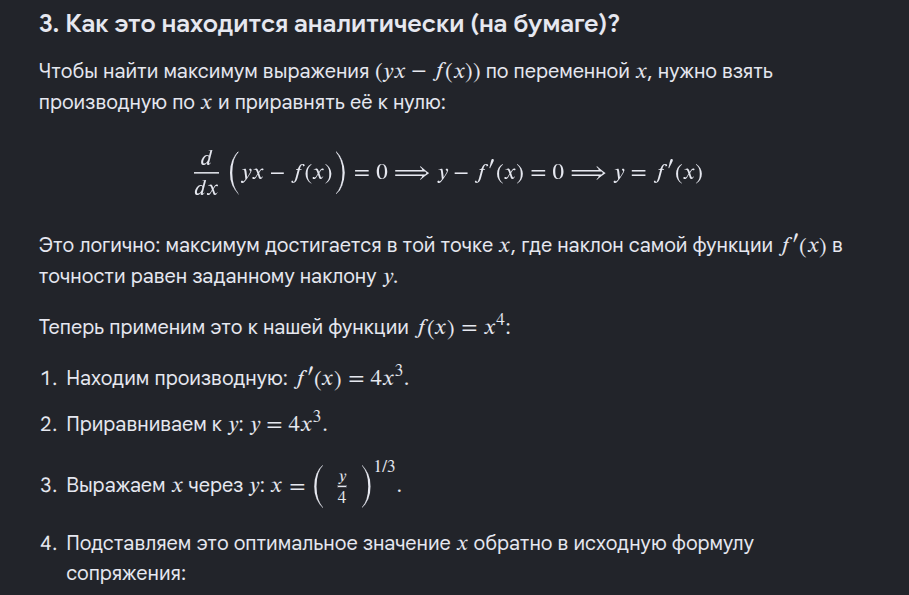

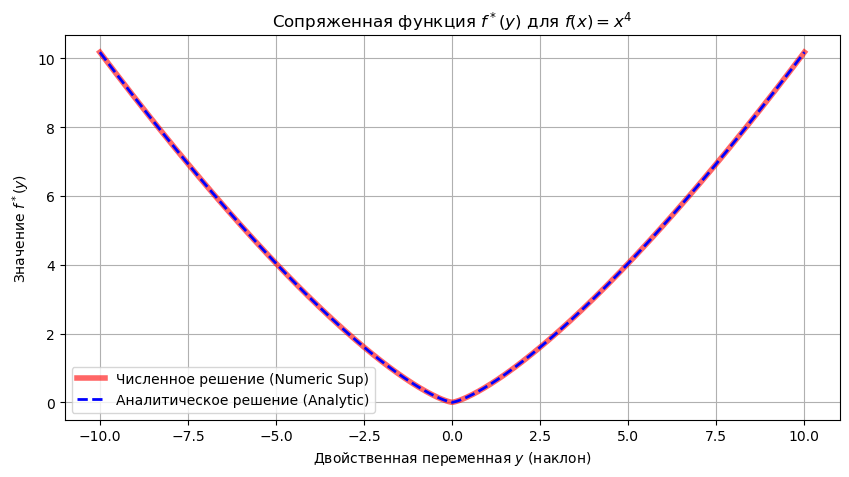

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Исходная функция
def f(x):
    return x**4


# 2. Аналитическая сопряженная функция
def f_conjugate_analytic(y):
    # Коэффициент: 3 / (4**(4/3))
    coef = 3 / (4 ** (4 / 3))
    return coef * (np.abs(y) ** (4 / 3))


# 3. Численное преобразование Лежандра-Фенхеля
def f_conjugate_numeric(y_grid, x_grid):
    f_star = []
    for y in y_grid:
        # Реализуйте поиск максимума функции (y*x - f(x)) по всей сетке x_grid
        # Ваш код здесь:
        val = np.max(y * x_grid - f(x_grid))  # Замените на вычисление супремума
        f_star.append(val)
    return np.array(f_star)


# Сетки для вычислений
x_grid = np.linspace(-5, 5, 1000)
y_grid = np.linspace(-10, 10, 500)

# Вычисление
f_star_numeric = f_conjugate_numeric(y_grid, x_grid)
f_star_analytic = f_conjugate_analytic(y_grid)

# Визуализация (допишите построение графиков для сравнения численного и аналитического решений)
plt.figure(figsize=(10, 5))
plt.plot(y_grid, f_star_numeric, label="Численное решение (Numeric Sup)", color="red", lw=4, alpha=0.6)
plt.plot(y_grid, f_star_analytic, label="Аналитическое решение (Analytic)", color="blue", linestyle="--", lw=2)

plt.title("Сопряженная функция $f^*(y)$ для $f(x) = x^4$")
plt.xlabel("Двойственная переменная $y$ (наклон)")
plt.ylabel("Значение $f^*(y)$")
plt.legend()
plt.grid(True)
plt.show()

Задание 2. Визуализация опорного гиперплана и субдифференциала

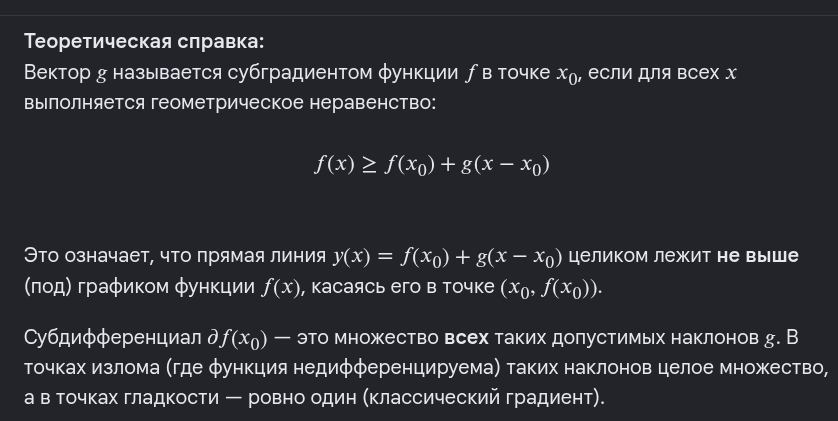

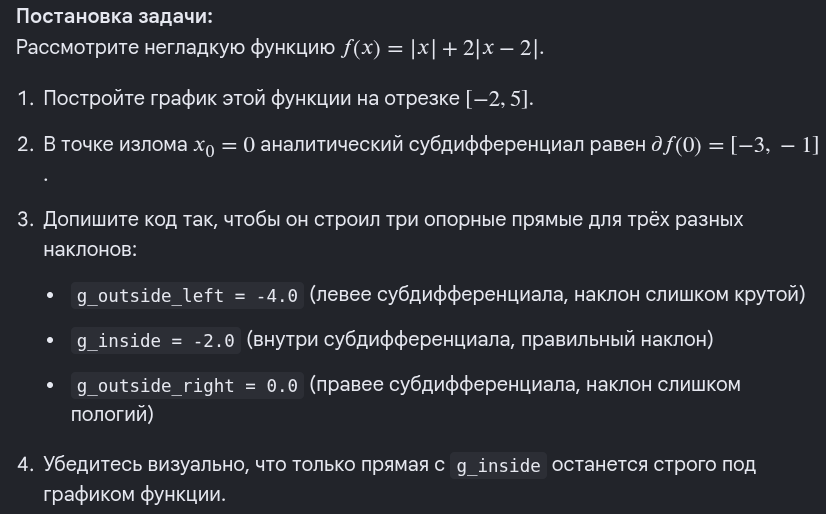

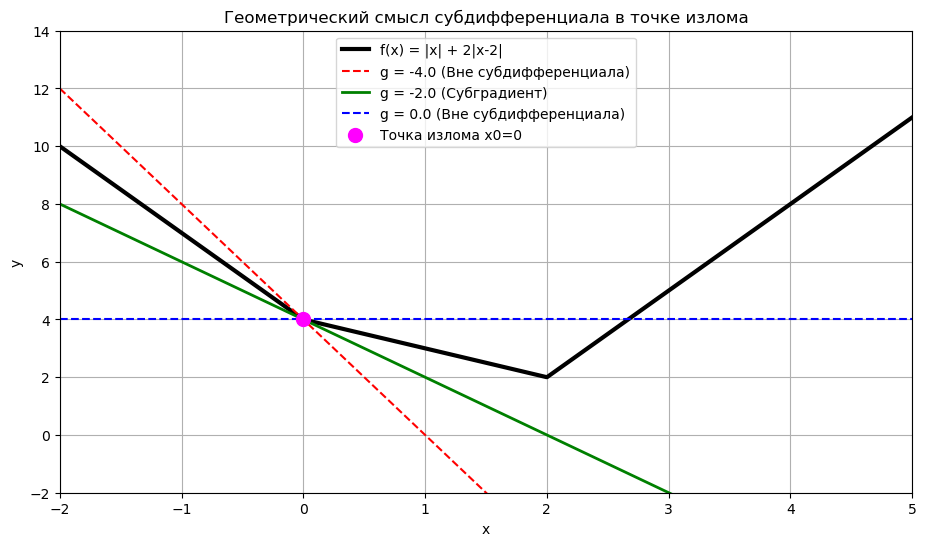

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Исходная негладкая функция
def f(x):
    return np.abs(x) + 2 * np.abs(x - 2)


# Сетка для отрисовки графика
x_grid = np.linspace(-2, 5, 1000)

# Исследуемая точка излома
x0 = 0
f_x0 = f(x0)  # Значение функции в этой точке

# Три тестовых наклона (субградиента)
g_outside_left = -4.0  # Ошибка: вылетит НАД графиком справа
g_inside = -2.0  # Истинный субградиент: останется ПОД графиком
g_outside_right = 0.0  # Ошибка: вылетит НАД графиком слева

plt.figure(figsize=(11, 6))
# Строим саму функцию
plt.plot(x_grid, f(x_grid), label="f(x) = |x| + 2|x-2|", color="black", lw=3)

# -------------------------------------------------------------------------
# ЗАДАНИЕ: Допишите формулы для трех прямых вида: f_x0 + g * (x_grid - x0)
# -------------------------------------------------------------------------
# Прямая 1 (Неверный наклон слева)
line_left = f_x0 + g_outside_left * (x_grid - x0)
plt.plot(x_grid, line_left, "--", label="g = -4.0 (Вне субдифференциала)", color="red")

# Прямая 2 (Верный наклон внутри субдифференциала)
line_inside = f_x0 + g_inside * (x_grid - x0)
plt.plot(x_grid, line_inside, "-", label="g = -2.0 (Субградиент)", color="green", lw=2)

# Прямая 3 (Неверный наклон справа)
line_right = f_x0 + g_outside_right * (x_grid - x0)
plt.plot(x_grid, line_right, "--", label="g = 0.0 (Вне субдифференциала)", color="blue")
# -------------------------------------------------------------------------

# Отмечаем точку исследования
plt.scatter([x0], [f_x0], color="magenta", s=100, zorder=5, label=f"Точка излома x0={x0}")

plt.title("Геометрический смысл субдифференциала в точке излома")
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-2, 14)
plt.xlim(-2, 5)
plt.legend()
plt.grid(True)
plt.show()

Задание 3. Субградиентный спуск для негладкой функции (Lasso-подобная задача)

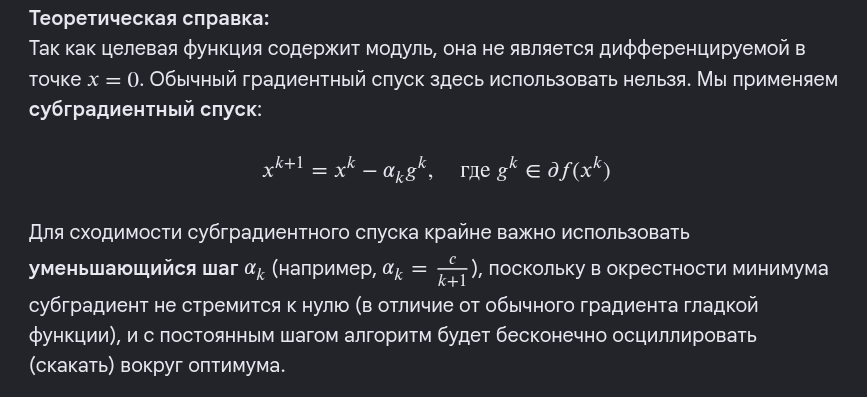

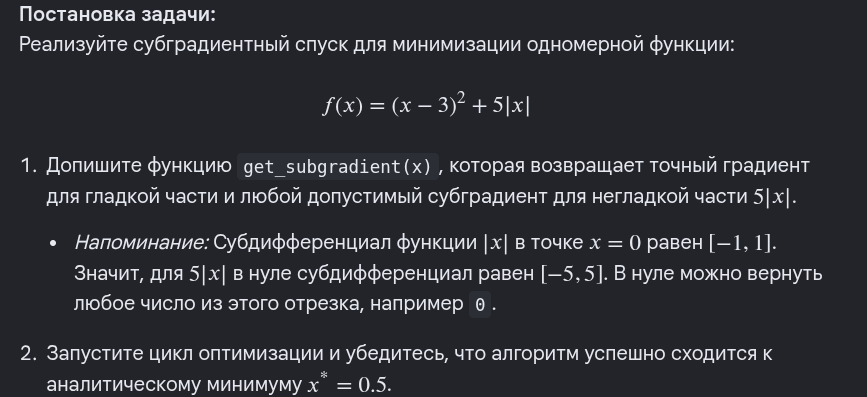

Итоговая найденная точка минимума: 0.5000
Значение функции в ней: 8.7500


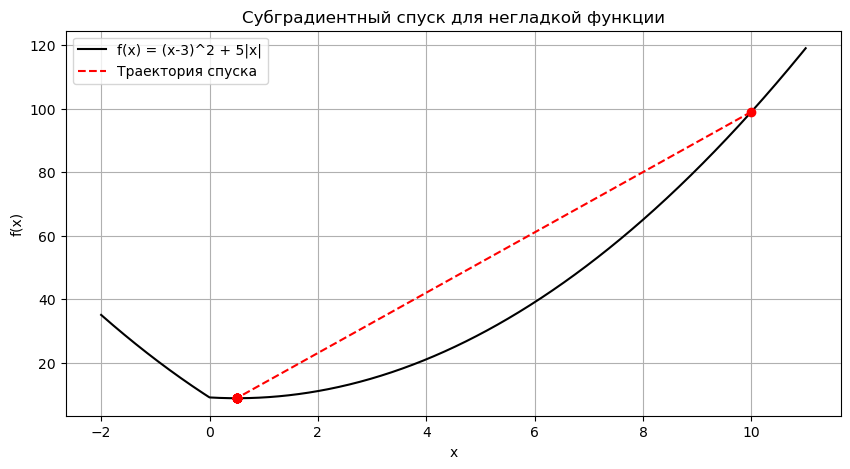

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Целевая функция
def f(x):
    return (x - 3) ** 2 + 5 * np.abs(x)


# 2. Функция вычисления субградиента
def get_subgradient(x):
    # Градиент гладкой части (x - 3)**2 равен 2 * (x - 3)
    # Субградиент негладкой части 5 * |x| равен:
    #   5 * sign(x), если x != 0
    #   любое число из [-5, 5], если x == 0

    # -------------------------------------------------------------------------
    # ЗАДАНИЕ: Допишите расчет субградиента g
    # -------------------------------------------------------------------------
    # Подсказка: используйте np.sign(x), но обработайте случай x == 0 отдельно,
    # либо аккуратно верните значение.

    if x > 0:
        g = 2 * (x - 3) + 5
    elif x < 0:
        g = 2 * (x - 3) - 5
    else:
        g = 2 * (x - 3) + 0  # Выбрали 0 из подмножества [-5, 5] в точке излома

    return g
    # -------------------------------------------------------------------------


# Параметры алгоритма
x_k = 10.0  # Начальное приближение (берем далеко от минимума)
iterations = 100
history = [x_k]

# Цикл субградиентного спуска
for k in range(iterations):
    # Уменьшающийся шаг: alpha_k = c / (k + 1)
    alpha = 0.5 / (k + 1)

    g = get_subgradient(x_k)

    # Делаем шаг против субградиента
    x_k = x_k - alpha * g
    history.append(x_k)

print(f"Итоговая найденная точка минимума: {x_k:.4f}")
print(f"Значение функции в ней: {f(x_k):.4f}")

# Визуализация сходимости
plt.figure(figsize=(10, 5))
x_grid = np.linspace(-2, 11, 1000)
plt.plot(x_grid, f(x_grid), color="black", label="f(x) = (x-3)^2 + 5|x|")

# Отрисуем первые 15 шагов, чтобы увидеть траекторию
plt.scatter(history[:15], [f(x) for x in history[:15]], color="red", zorder=5)
plt.plot(history[:15], [f(x) for x in history[:15]], color="red", linestyle="--", label="Траектория спуска")

plt.title("Субградиентный спуск для негладкой функции")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()